# 19 — Identification at scale + verification (public mouse-dynamics corpora)

**Phase 6** ([docs/ROADMAP.md](../docs/ROADMAP.md)). The single most damaging question a reviewer can ask this project is *"does the method survive beyond 3 friends?"* This notebook answers it — without recruiting anyone — by running the **exact GTA windowed-feature pipeline** on two public corpora, then reframing identification as the problem the industry actually has: **verification** (*"is this account being played by its usual owner?"* — account sharing, smurfing, boosting) and **open-set rejection** (*"none of the enrolled players"*).

| Corpus | Users | Data per user | Role |
|---|---|---|---|
| **Balabit** Mouse Dynamics Challenge | 10 | hours (desktop sessions) | the literature benchmark → comparable EER |
| **SapiMouse** | 120 | minutes (1-min + 3-min tasks) | the scale stress-test |

Three things to know before the numbers:

1. **Mouse-only.** These corpora have no keyboard channel, so models use `MOUSE_ID_FEATURE_COLS` (17 features) — keyboard features are *excluded*, not zero-filled. GTA's 0.85 isn't directly comparable: SHAP (notebook 12) showed the GTA fingerprint is partly keyboard timing.
2. **Idle-gap segmentation.** Balabit sessions are hours-long desktop captures dominated by idle time; the GTA windowing assumes continuous play and stopped at the first empty 30 s window (a 4-hour session yielded 3 windows!). `split_on_idle` segments at >10 s gaps first — the standard treatment in the mouse-dynamics literature.
3. **Reproducibility.** Everything here reuses the seeded experiment code in [`scripts/run_external_identification.py`](../scripts/run_external_identification.py); the committed [`reports/external_identification.json`](../reports/external_identification.json) feeds the README results block (CI-gated).

## 0. Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from pipeline.features.run import ID_FEATURE_COLS, MOUSE_ID_FEATURE_COLS
from scripts.run_external_identification import (
    BALABIT_DIR,
    fit_classifier,
    predict_proba,
    session_windows,
    windows_frame,
)

report = json.loads((ROOT / "reports" / "external_identification.json").read_text())

n_id, n_mouse = len(ID_FEATURE_COLS), len(MOUSE_ID_FEATURE_COLS)
print(f"GTA identifier uses {n_id} features — mouse-only slice keeps {n_mouse}.")
print("dropped (keyboard channel):", sorted(set(ID_FEATURE_COLS) - set(MOUSE_ID_FEATURE_COLS)))

GTA identifier uses 25 features — mouse-only slice keeps 17.
dropped (keyboard channel): ['burst_rate', 'hold_mean', 'hold_std', 'iki_mean', 'iki_std', 'keystroke_periodicity', 'mouse_key_ratio', 'wasd_rhythm']


## 1. From corpus CSV to pipeline windows — one session, end to end

The adapters (`pipeline/external/`) translate each corpus into **recorder-schema sessions**, the same drop-in trick the synthetic cheat generator uses — so ingestion → windowing → features run *unchanged*. Two real-data lessons surfaced while building them:

- Balabit contains **`(65535, 65535)` sentinel-glitch rows** (uint16 max, ~1 per session) that overflow the pipeline's Int16 event schema → parsers drop coordinates outside `[0, 32000]`.
- Idle gaps: below, the segmentation effect on one real Balabit session.

In [2]:
from pipeline.external.balabit import BalabitAdapter
from pipeline.external.base import split_on_idle
from pipeline.ingestion.run import parse_events

adapter = BalabitAdapter(BALABIT_DIR)
session = next(adapter.iter_sessions())
events = parse_events(session)
segments = split_on_idle(events)

span_h = session["duration_ms"] / 3.6e6
active_s = sum(s["t"].iloc[-1] - s["t"].iloc[0] for s in segments) / 1000
print(f"{session['session_id']}: {session['event_count']} events spanning {span_h:.1f} h")
print(f"→ {len(segments)} activity segments, {active_s/60:.1f} min of actual activity")

wins = session_windows(session)
print(f"→ {len(wins)} feature windows (vs 3 without segmentation — the bug this catches)")

balabit_user12_session_2144641057: 30286 events spanning 4.3 h
→ 67 activity segments, 103.4 min of actual activity


→ 245 feature windows (vs 3 without segmentation — the bug this catches)


## 2. Closed-set identification — the users-curve

**SapiMouse protocol** (the paper's own): train on each user's 3-minute session, test on their 1-minute session — session-held-out by construction, and a deliberate stress test: that's **~6 training windows per user**.

The runner sweeps enrolment size 3 → 120 (5 user-draws below the maximum, fixed seed). The question is not "is accuracy high" — with seconds of data it won't be — but **how the signal degrades**: gracefully (stays a large multiple of chance) or collapsing.

At 120 users: acc 0.110 (CI 0.08–0.14, chance 0.0083 → 13× chance)


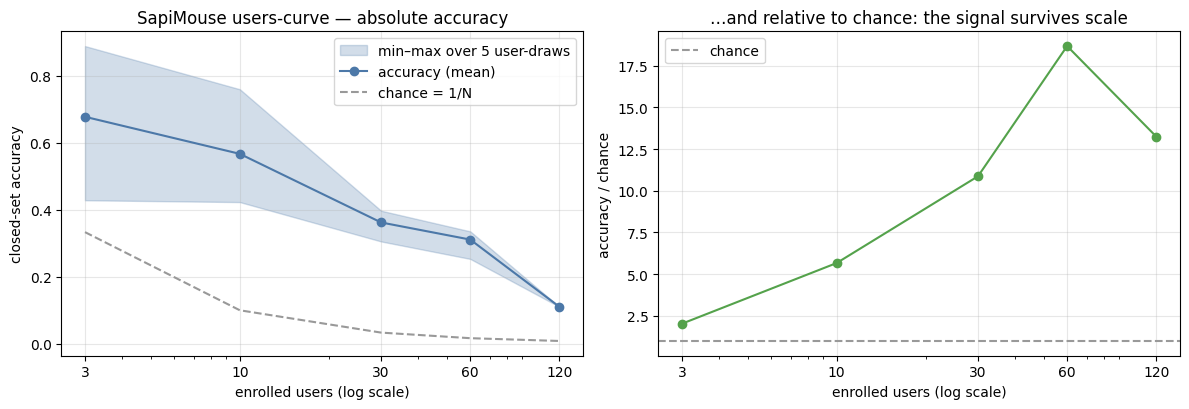

In [3]:
sap = report["sapimouse"]
curve = sap["users_curve"]

ns = [e["n_users"] for e in curve]
means = [e["accuracy_mean"] for e in curve]
mins = [e["accuracy_min"] for e in curve]
maxs = [e["accuracy_max"] for e in curve]
chance = [e["chance"] for e in curve]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
ax1.fill_between(ns, mins, maxs, alpha=0.25, color="#4c78a8", label="min–max over 5 user-draws")
ax1.plot(ns, means, "o-", color="#4c78a8", label="accuracy (mean)")
ax1.plot(ns, chance, "--", color="#999", label="chance = 1/N")
ax1.set_xscale("log")
ax1.set_xticks(ns)
ax1.set_xticklabels(ns)
ax1.set_xlabel("enrolled users (log scale)")
ax1.set_ylabel("closed-set accuracy")
ax1.set_title("SapiMouse users-curve — absolute accuracy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ratio = [m / c for m, c in zip(means, chance)]
ax2.plot(ns, ratio, "o-", color="#54a24b")
ax2.axhline(1.0, color="#999", linestyle="--", label="chance")
ax2.set_xscale("log")
ax2.set_xticks(ns)
ax2.set_xticklabels(ns)
ax2.set_xlabel("enrolled users (log scale)")
ax2.set_ylabel("accuracy / chance")
ax2.set_title("…and relative to chance: the signal survives scale")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig.tight_layout()

full = curve[-1]
print(f"At {full['n_users']} users: acc {full['accuracy_mean']:.3f} "
      f"(CI {full['accuracy_ci95'][0]:.2f}–{full['accuracy_ci95'][1]:.2f}, "
      f"chance {full['chance']:.4f} → {full['accuracy_mean']/full['chance']:.0f}× chance)")

**Read:** absolute accuracy falls as enrolment grows (left) — inevitable with ~6 windows/user — but stays **10–20× chance all the way to 120 users** (right). The fingerprint doesn't collapse beyond 3 friends; it's *data-starved*, which is a different, fixable problem (Phase 8).

## 3. Verification — the product reframe (Balabit's real impostor task)

Balabit ships exactly the industry problem: test sessions sit in a *claimed* user's directory, and `public_labels.csv` says whether the claim is genuine or an **impostor** (816 labelled sessions). We train the multiclass identifier on all training windows, score each test session as **mean P(claimed user)** over its windows, and report the **DET curve + EER** — the standard biometric headline.

*(This cell recomputes the verification scores live — ≈90 s: feature-extract 65 training sessions, fit, score 784 labelled test sessions.)*

In [4]:
from pipeline.verification import det_curve, eer

feats = windows_frame(adapter.iter_sessions())
model, scaler, le = fit_classifier(feats)

genuine, impostor = [], []
for sess, claimed, is_impostor in adapter.iter_test_sessions():
    wins = session_windows(sess)
    if wins.empty or claimed not in set(le.classes_):
        continue
    proba = predict_proba(model, scaler, wins)
    score = float(proba[:, int(np.where(le.classes_ == claimed)[0][0])].mean())
    (impostor if is_impostor else genuine).append(score)

genuine, impostor = np.array(genuine), np.array(impostor)
e, thr = eer(genuine, impostor)
print(f"{len(genuine)} genuine / {len(impostor)} impostor sessions → EER {e:.3f} @ threshold {thr:.3f}")

395 genuine / 389 impostor sessions → EER 0.144 @ threshold 0.206


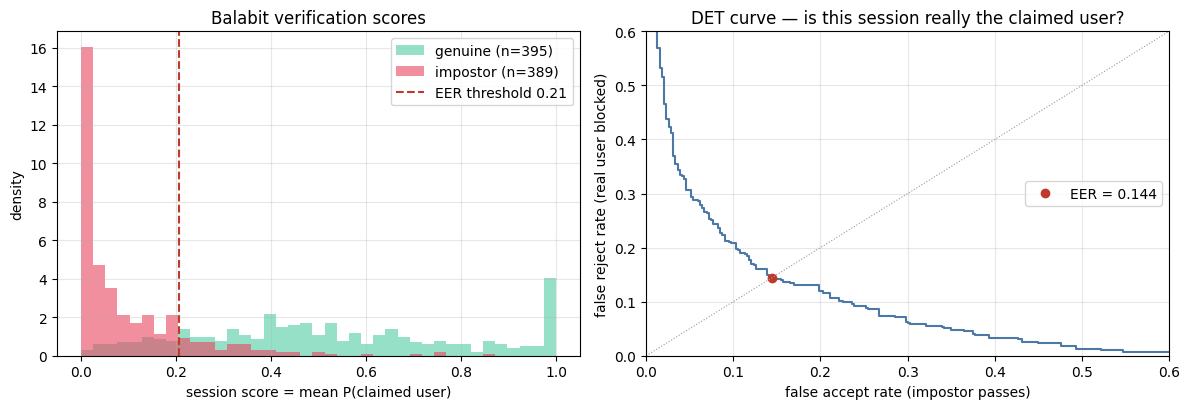

In [5]:
far, frr, _ = det_curve(genuine, impostor)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
bins = np.linspace(0, 1, 40)
ax1.hist(genuine, bins=bins, alpha=0.6, color="#4ecca3", density=True, label=f"genuine (n={len(genuine)})")
ax1.hist(impostor, bins=bins, alpha=0.6, color="#e94560", density=True, label=f"impostor (n={len(impostor)})")
ax1.axvline(thr, color="#c0392b", linestyle="--", label=f"EER threshold {thr:.2f}")
ax1.set_xlabel("session score = mean P(claimed user)")
ax1.set_ylabel("density")
ax1.set_title("Balabit verification scores")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(far, frr, color="#4c78a8")
ax2.plot([e], [e], "o", color="#c0392b", label=f"EER = {e:.3f}")
ax2.plot([0, 1], [0, 1], ":", color="#999", linewidth=0.8)
ax2.set_xlabel("false accept rate (impostor passes)")
ax2.set_ylabel("false reject rate (real user blocked)")
ax2.set_xlim(0, 0.6)
ax2.set_ylim(0, 0.6)
ax2.set_title("DET curve — is this session really the claimed user?")
ax2.legend()
ax2.grid(True, alpha=0.3)
fig.tight_layout()

**Read:** EER ≈ **0.14** from *generic* windowed features + LightGBM with zero corpus-specific tuning. Challenge-era dedicated methods report roughly 7–25% depending on data volume per decision — so the unmodified GTA pipeline lands squarely in the credible range on the public benchmark. In anti-cheat terms (MODEL_CARD's ban-cost asymmetry): at the EER threshold you'd wrongly block ~14% of legitimate sessions — usable for *ranking suspicion*, not for automated action; production systems operate at much lower FAR and aggregate more evidence per decision.

## 4. Open-set — "none of the enrolled players"

Enrol half the SapiMouse users, hold the other 60 out as people the model has **never seen**, and ask the closed-set classifier to reject them via its max softmax probability.

In [6]:
osr = sap["open_set"]
print(f"enrolled {osr['n_enrolled']} / unknown {osr['n_unknown']} users")
print(f"open-set EER {osr['eer']:.3f}  (0.5 = chance)")
print(f"FAR at FRR≤5%: {osr['far_at_frr05']:.2f} — i.e. rejecting ≤5% of real users lets "
      f"{osr['far_at_frr05']:.0%} of unknowns through")

enrolled 60 / unknown 60 users
open-set EER 0.483  (0.5 = chance)
FAR at FRR≤5%: 0.93 — i.e. rejecting ≤5% of real users lets 93% of unknowns through


**Read: chance-level.** Closed-set softmax confidence is **not** an identity score at this data volume — an unknown user simply lands on whichever enrolled user they resemble, with full confidence. This is the cleanest measured argument in the project for (a) **Phase 8 pretraining** (a human-motion prior so per-user data goes further) and (b) **embedding / metric-learning verification** (score = distance to the enrolled template, not classifier confidence).

## 5. Findings

| Claim | Evidence |
|---|---|
| The fingerprint **survives scale** | 10–20× chance at every enrolment size to 120 users (§2) |
| It is **data-bound, not method-bound**, at the small end | Balabit (hours/user) → EER 0.14; SapiMouse (minutes/user) → data-starved (§2 vs §3) |
| The pipeline **transfers as-is** to the literature benchmark | EER 0.144 on Balabit's real impostor task, zero tuning (§3) |
| **Open-set is the hard frontier** | EER ≈ 0.48 with softmax confidence (§4) → Phase 8 + metric learning |

Everything regenerates with `python -m scripts.run_external_identification` (seed 42); the README results rows are rendered from the JSON by `scripts/generate_results.py` and CI fails if they drift. Full write-up: [docs/VERIFICATION.md](../docs/VERIFICATION.md).